<a href="https://colab.research.google.com/github/sathkumara-smna/258739K/blob/main/Site_Power_Prection_Eng_Rule.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

site_db_url = "https://raw.githubusercontent.com/sathkumara-smna/258739K/main/site_power%20from%20Sey.xlsx"
site_db = pd.read_excel(site_db_url)
site_db.head(2)

,Site_ID,trigger_ID,date,datetime,site_power
0,101,1,2026-03-01,2026-03-01 00:00,6517.6299
1,101,2,2026-03-01,2026-03-01 00:15,6533.5512


In [26]:
power_2g3g_url = "https://raw.githubusercontent.com/sathkumara-smna/258739K/main/site_power_2g3g.xlsx"
power_2g3g = pd.read_excel(power_2g3g_url)
power_2g3g.head(2)

,Site_ID,rru_count_2g,rru_2g_bp,power_2g,rru_count_3g,rru_3g_bp,power_3g,total_2g_3g_power
0,101,3,150,450,7,200,1400,1850
1,102,2,150,300,4,200,800,1100


In [27]:
power_4g_url = "https://raw.githubusercontent.com/sathkumara-smna/258739K/main/site_power_lte.xlsx"
power_4g = pd.read_excel(power_4g_url)
power_4g.head(2)

,Site_ID,trigger_ID,date,datetime,site_power
0,101,1,2026-03-01,2026-03-01 00:00,2470.12
1,101,2,2026-03-01,2026-03-01 00:15,2473.34


In [28]:
power_5g_url = "https://raw.githubusercontent.com/sathkumara-smna/258739K/main/site_power_5g.xlsx"
power_5g = pd.read_excel(power_5g_url)
power_5g.head(2)

,Site_ID,trigger_ID,date,datetime,site_5g_power
0,101,1,2026-03-01,2026-03-01 00:00,1752.97
1,101,2,2026-03-01,2026-03-01 00:15,1762.42


In [29]:
# Add power_2g3g column to site_db using Site_ID matching

site_db['power_2g3g'] = (

    site_db['Site_ID'].map(power_2g3g.set_index('Site_ID')['total_2g_3g_power'])
)
# Show first rows
site_db.head(2)

,Site_ID,trigger_ID,date,datetime,site_power,power_2g3g
0,101,1,2026-03-01,2026-03-01 00:00,6517.6299,1850
1,101,2,2026-03-01,2026-03-01 00:15,6533.5512,1850


In [30]:
# Add 4G power column to site_db
# Matching using Site_ID, trigger_ID, and date

site_db = site_db.merge(

    power_4g[
        ['Site_ID', 'trigger_ID', 'date', 'site_power']
    ].rename(columns={'site_power': 'power_4g'}),

    on=['Site_ID', 'trigger_ID', 'date'],how='left')

# Show first rows
site_db.head(2)

,Site_ID,trigger_ID,date,datetime,site_power,power_2g3g,power_4g
0,101,1,2026-03-01,2026-03-01 00:00,6517.6299,1850,2470.12
1,101,2,2026-03-01,2026-03-01 00:15,6533.5512,1850,2473.34


In [31]:
# Add 5G power column to site_db
# Matching using Site_ID, trigger_ID, and date

site_db = site_db.merge(

    power_5g[
        ['Site_ID', 'trigger_ID', 'date', 'site_5g_power']
    ].rename(columns={'site_5g_power': 'power_5g'}
    ),
    on=['Site_ID', 'trigger_ID', 'date'],
    how='left'

)
# Show first rows
site_db.head(2)

,Site_ID,trigger_ID,date,datetime,site_power,power_2g3g,power_4g,power_5g
0,101,1,2026-03-01,2026-03-01 00:00,6517.6299,1850,2470.12,1752.97
1,101,2,2026-03-01,2026-03-01 00:15,6533.5512,1850,2473.34,1762.42


In [32]:
# Replace empty values with 0

site_db['power_2g3g'] = (site_db['power_2g3g'].fillna(0))
site_db['power_4g'] = (site_db['power_4g'].fillna(0))
site_db['power_5g'] = (site_db['power_5g'].fillna(0))

# Recalculate total predicted power
site_db['site_total_predicted_power'] = (site_db['power_2g3g']+site_db['power_4g']+site_db['power_5g'])
# Show first rows
site_db.head(2)

,Site_ID,trigger_ID,date,datetime,site_power,power_2g3g,power_4g,power_5g,site_total_predicted_power
0,101,1,2026-03-01,2026-03-01 00:00,6517.6299,1850,2470.12,1752.97,6073.09
1,101,2,2026-03-01,2026-03-01 00:15,6533.5512,1850,2473.34,1762.42,6085.76


In [33]:
# ============================================================
# ERROR COLUMN
# ============================================================
site_db['error'] = (site_db['site_power']-site_db['site_total_predicted_power'])
# ============================================================
# SHOW RESULTS
# ============================================================

site_db.head(2)

,Site_ID,trigger_ID,date,datetime,site_power,power_2g3g,power_4g,power_5g,site_total_predicted_power,error
0,101,1,2026-03-01,2026-03-01 00:00,6517.6299,1850,2470.12,1752.97,6073.09,444.5399
1,101,2,2026-03-01,2026-03-01 00:15,6533.5512,1850,2473.34,1762.42,6085.76,447.7912


In [34]:
# ============================================================
# ERROR PERCENTAGE COLUMN
# ============================================================

site_db['error_percentage'] = (

    site_db['error']

    /

    site_db['site_power']

) * 100

# ============================================================
# SHOW RESULTS
# ============================================================

site_db.head(2)

,Site_ID,trigger_ID,date,datetime,site_power,power_2g3g,power_4g,power_5g,site_total_predicted_power,error,error_percentage
0,101,1,2026-03-01,2026-03-01 00:00,6517.6299,1850,2470.12,1752.97,6073.09,444.5399,6.820576
1,101,2,2026-03-01,2026-03-01 00:15,6533.5512,1850,2473.34,1762.42,6085.76,447.7912,6.853718


In [35]:
print(site_db.columns)

Index(['Site_ID', 'trigger_ID', 'date', 'datetime', 'site_power', 'power_2g3g',
       'power_4g', 'power_5g', 'site_total_predicted_power', 'error',
       'error_percentage'],
      dtype='object')


In [36]:
site_db.to_excel('Total_Power_Prediction_Eng_Rule.xlsx',index=False)

In [37]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

y_true = site_db['site_power']

y_pred = site_db['site_total_predicted_power']

# ============================================================
# MAE
# ============================================================

mae = mean_absolute_error(
    y_true,
    y_pred
)

# ============================================================
# RMSE
# ============================================================

rmse = np.sqrt(

    mean_squared_error(
        y_true,
        y_pred
    )

)

# ============================================================
# MAPE
# ============================================================

mape = np.mean(

    np.abs(

        (
            y_true - y_pred
        )

        /

        y_true

    )

) * 100

# ============================================================
# R2
# ============================================================

r2 = r2_score(
    y_true,
    y_pred
)

# ============================================================
# PRINT RESULTS
# ============================================================

print("================================")
print("ENGINEERING RULE PERFORMANCE")
print("================================")

print(f"MAE               : {round(mae, 2)}")
print(f"RMSE              : {round(rmse, 2)}")
print(f"MAPE              : {round(mape, 2)} %")
print(f"R2                : {round(r2, 4)}")

ENGINEERING RULE PERFORMANCE
MAE               : 175.14
RMSE              : 251.0
MAPE              : 4.15 %
R2                : 0.9851


In [38]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import matplotlib.pyplot as plt

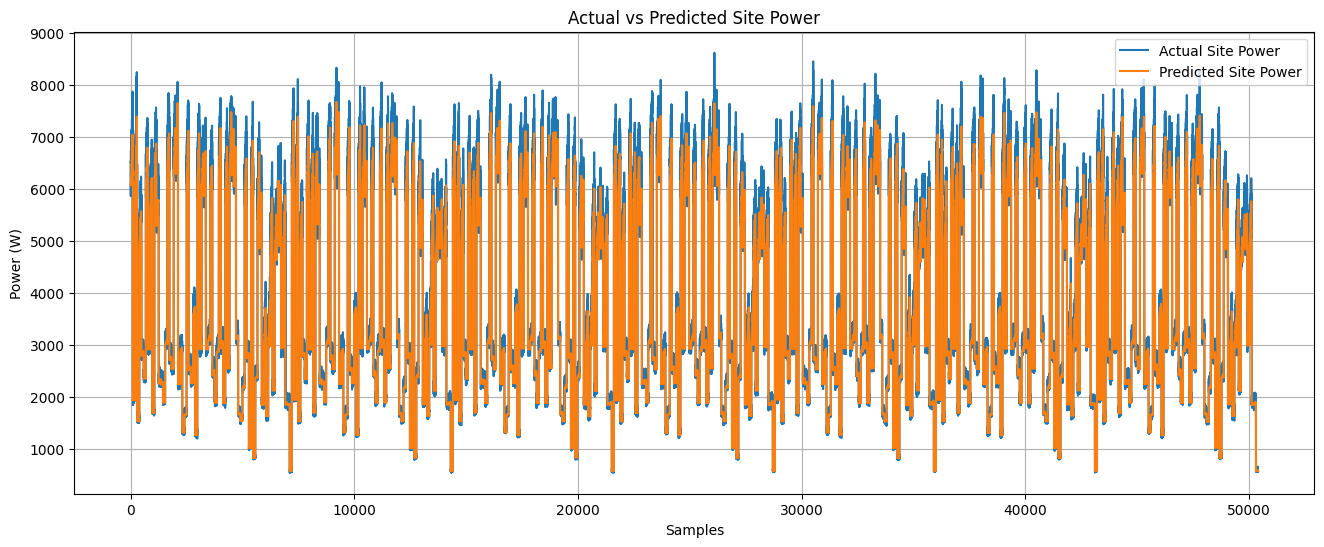

In [39]:
# ============================================================
# ACTUAL VS PREDICTED POWER GRAPH
# ============================================================

plt.figure(figsize=(16,6))


plt.plot(
    site_db['site_power'].values,
    label='Actual Site Power'
)
plt.plot(
    site_db['site_total_predicted_power'].values,
    label='Predicted Site Power'
)

plt.xlabel('Samples')
plt.ylabel('Power (W)')
plt.title('Actual vs Predicted Site Power')
plt.legend()
plt.grid(True)

plt.show()

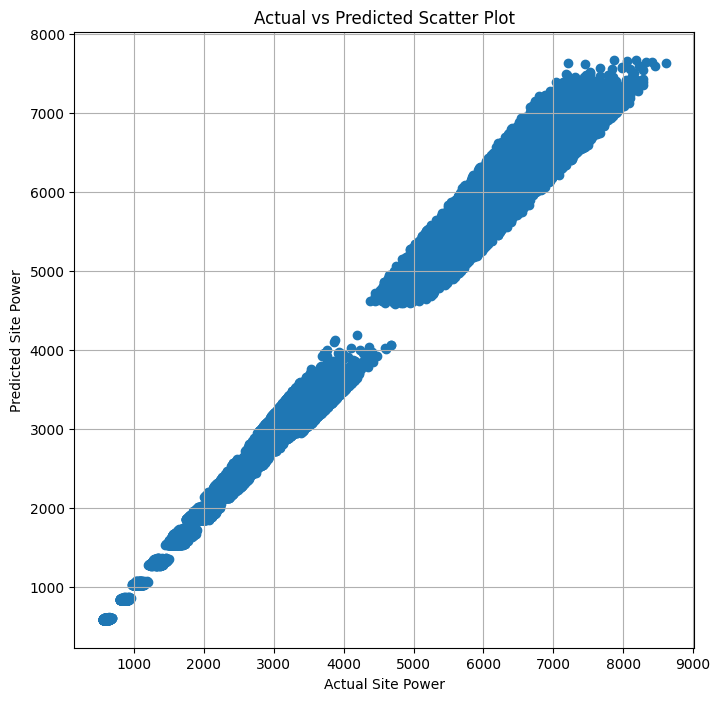

In [40]:
# ============================================================
# SCATTER PLOT
# ============================================================

plt.figure(figsize=(8,8))

plt.scatter(
    site_db['site_power'],
    site_db['site_total_predicted_power']
)

plt.xlabel('Actual Site Power')
plt.ylabel('Predicted Site Power')
plt.title('Actual vs Predicted Scatter Plot')
plt.grid(True)
plt.show()


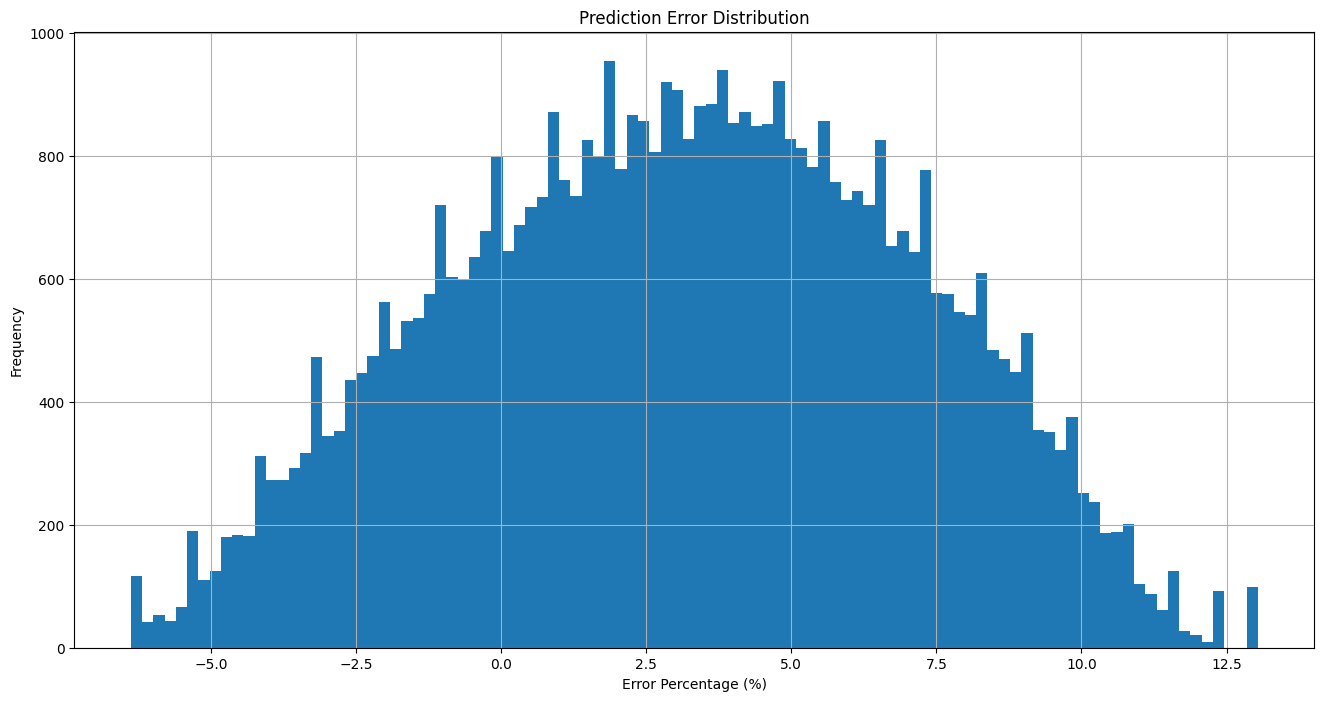

In [41]:
# ============================================================
# ERROR PERCENTAGE HISTOGRAM
# ============================================================

plt.figure(figsize=(16,8))

plt.hist(
    site_db['error_percentage'],
    bins=100
)

plt.xlabel('Error Percentage (%)')
plt.ylabel('Frequency')
plt.title('Prediction Error Distribution')
plt.grid(True)
plt.show()

In [42]:
# ============================================================
# CREATE ABSOLUTE ERROR COLUMN
# ============================================================

site_db = site_db.copy()

site_db['absolute_error'] = (

    abs(

        site_db['error']

    )

)

# ============================================================
# PICK MAXIMUM ABSOLUTE ERROR ROW PER SITE
# ============================================================

summary_df = (

    site_db.loc[

        site_db.groupby('Site_ID')['absolute_error'].idxmax()

    ]

)

# ============================================================
# KEEP REQUIRED COLUMNS
# ============================================================

summary_df = summary_df[

    [
        'Site_ID',
        'site_total_predicted_power',
        'site_power',
        'error',
        'error_percentage'
    ]

]

# ============================================================
# SORT BY SITE_ID
# ============================================================

summary_df = summary_df.sort_values(
    by='Site_ID'
)

# ============================================================
# RESET INDEX
# ============================================================

summary_df = summary_df.reset_index(drop=True)

# ============================================================
# EXPORT EXCEL
# ============================================================

summary_df.to_excel(

    "Total_Power_Prediction_Eng_Rule_Summary.xlsx",

    index=False

)

# ============================================================
# SHOW RESULTS
# ============================================================

summary_df.head()

,Site_ID,site_total_predicted_power,site_power,error,error_percentage
0,101,6731.59,7625.8285,894.2385,11.726444
1,102,1991.23,2225.9145,234.6845,10.543285
2,103,6746.99,7672.0385,925.0485,12.057402
3,104,1576.01,1764.6514,188.6414,10.690009
4,105,5829.29,6617.6835,788.3935,11.913436


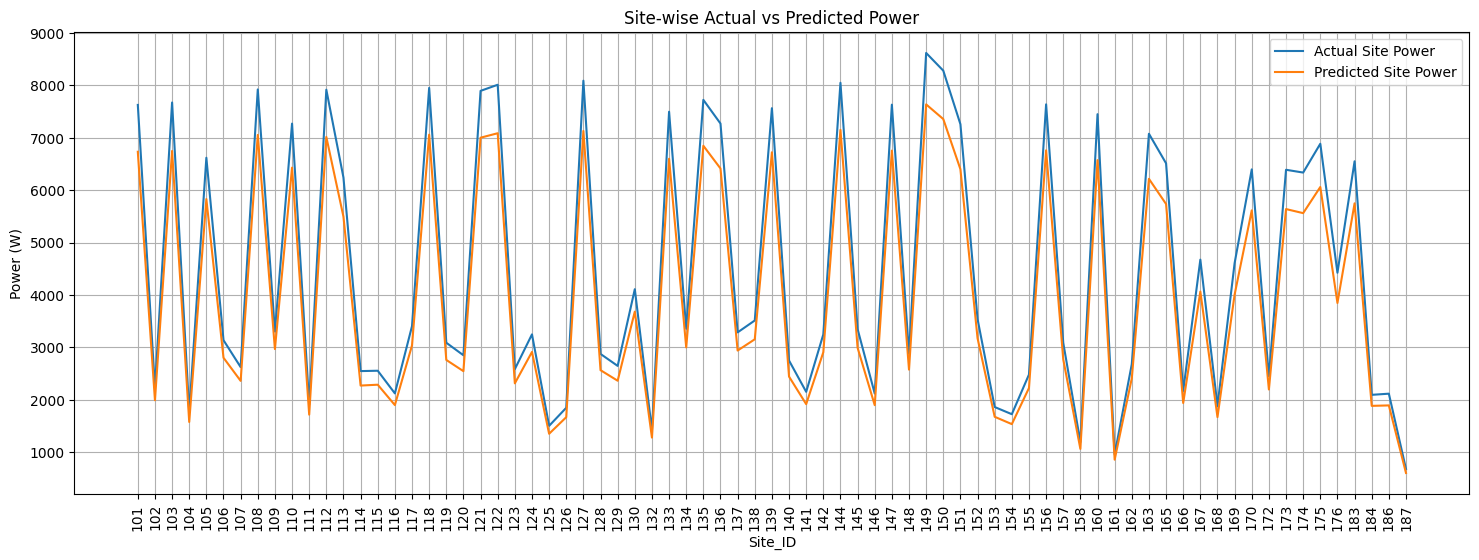

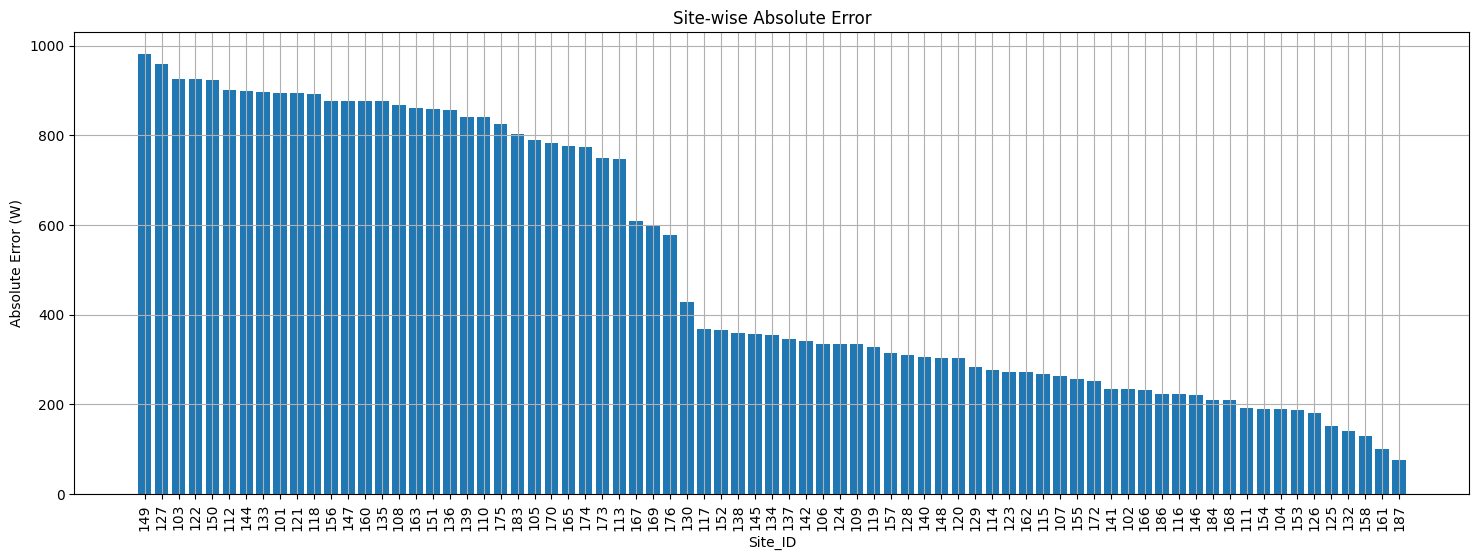

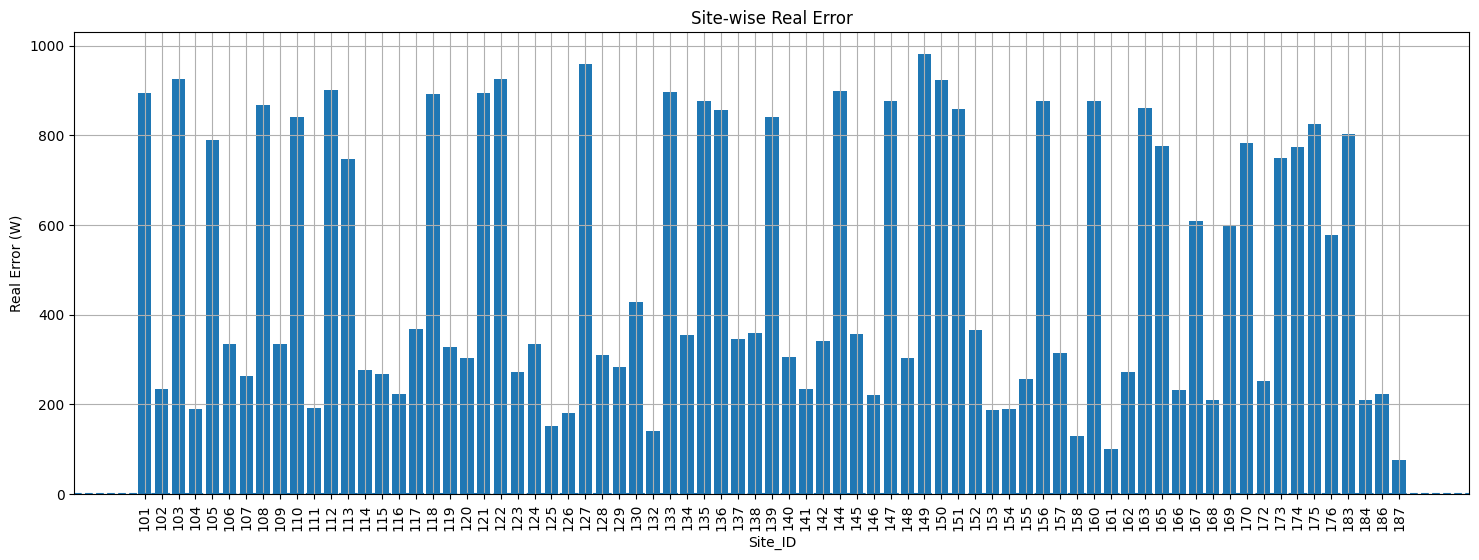

In [43]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import matplotlib.pyplot as plt

# ============================================================
# 1. SITE-WISE ACTUAL VS PREDICTED POWER
# ============================================================

plt.figure(figsize=(18,6))

plt.plot(
    summary_df['Site_ID'].astype(str),
    summary_df['site_power'],
    label='Actual Site Power'
)
plt.plot(
    summary_df['Site_ID'].astype(str),
    summary_df['site_total_predicted_power'],
    label='Predicted Site Power'

)
plt.xlabel('Site_ID')
plt.ylabel('Power (W)')
plt.title('Site-wise Actual vs Predicted Power')

plt.xticks(rotation=90)
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 2. ABSOLUTE ERROR SITE-WISE
# SORTED FROM MAXIMUM TO MINIMUM
# ============================================================

summary_df['absolute_error'] = (

    abs(summary_df['error'])

)

summary_df_abs_sorted = summary_df.sort_values(
    by='absolute_error',ascending=False)

plt.figure(figsize=(18,6))

plt.bar(

    summary_df_abs_sorted['Site_ID'].astype(str),

    summary_df_abs_sorted['absolute_error']

)

plt.xlabel('Site_ID')
plt.ylabel('Absolute Error (W)')
plt.title('Site-wise Absolute Error')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

# ============================================================
# 3. REAL ERROR SITE-WISE
# ============================================================

summary_df_real_sorted = summary_df.sort_values(
    by='Site_ID',
    ascending=True

)

plt.figure(figsize=(18,6))
plt.bar(
    summary_df_real_sorted['Site_ID'].astype(str),
    summary_df_real_sorted['error']
)

# Zero reference line

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Site_ID')
plt.ylabel('Real Error (W)')
plt.title('Site-wise Real Error')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

In [44]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import matplotlib.pyplot as plt


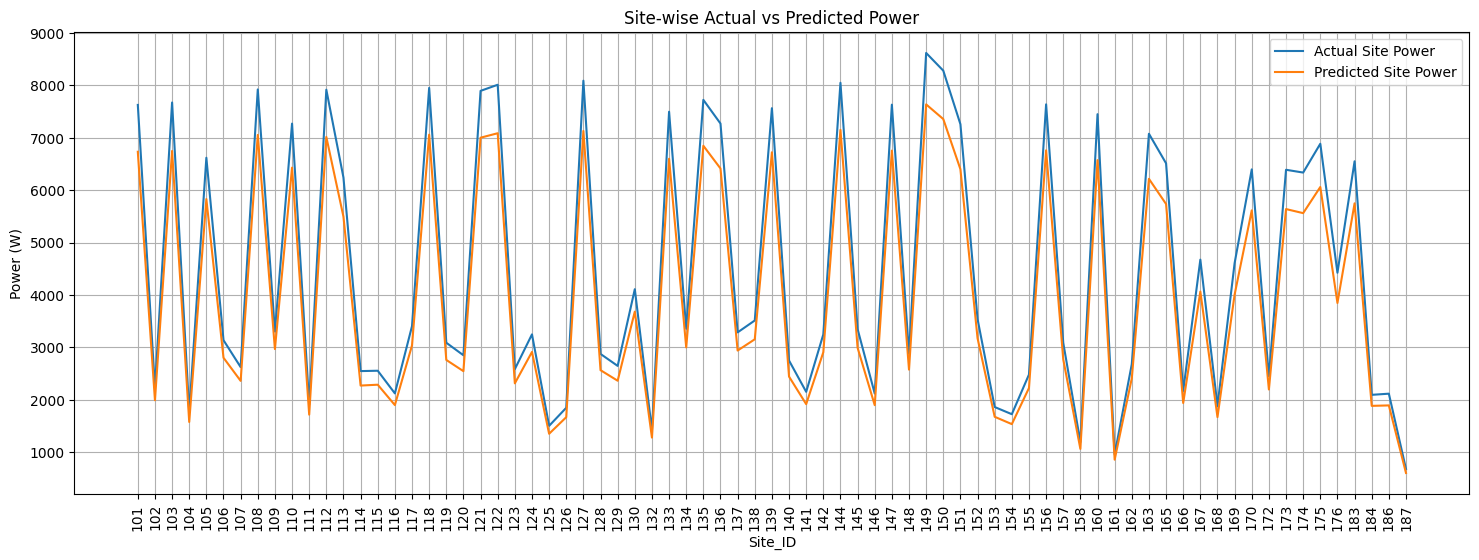

In [45]:
# ============================================================
# 1. ACTUAL VS PREDICTED POWER SITE-WISE
# SORTED BY SITE_ID
# ============================================================

summary_df_site_sorted = summary_df.sort_values(
    by='Site_ID',
    ascending=True)

plt.figure(figsize=(18,6))

plt.plot(
    summary_df_site_sorted['Site_ID'].astype(str),
    summary_df_site_sorted['site_power'],
    label='Actual Site Power'
)

plt.plot(
    summary_df_site_sorted['Site_ID'].astype(str),
    summary_df_site_sorted['site_total_predicted_power'],
    label='Predicted Site Power'
)

plt.xlabel('Site_ID')
plt.ylabel('Power (W)')
plt.title('Site-wise Actual vs Predicted Power')
plt.xticks(rotation=90)
plt.legend()
plt.grid(True)
plt.show()

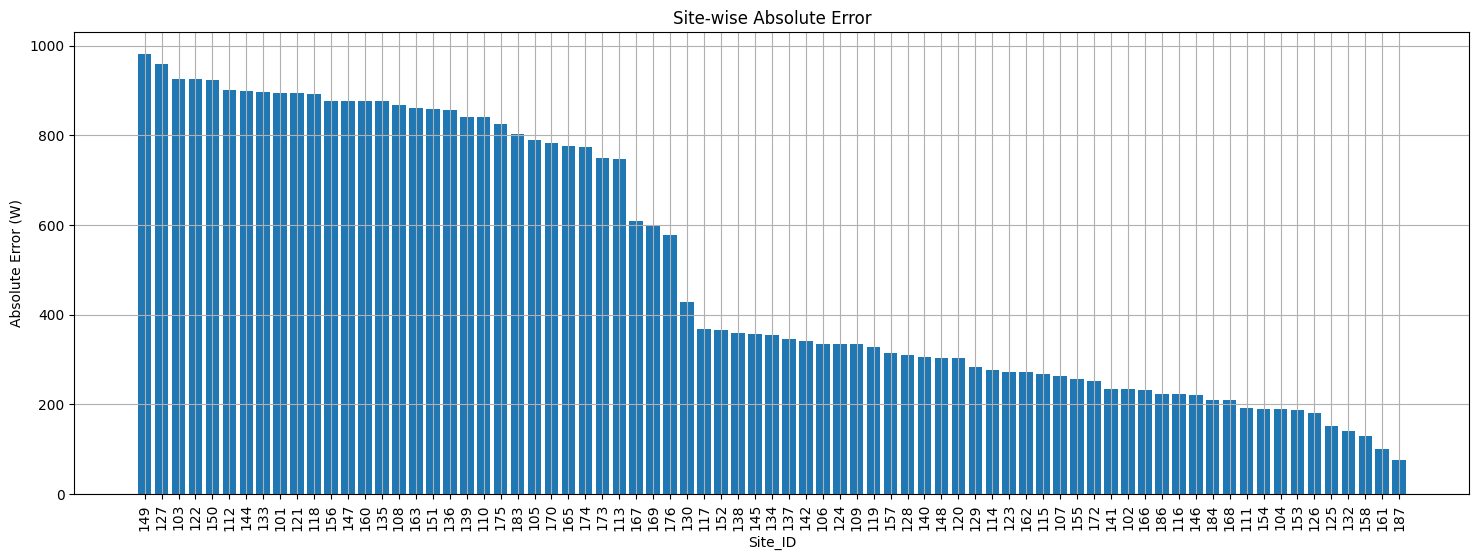

In [46]:
# ============================================================
# 2. ABSOLUTE ERROR SITE-WISE
# SORTED FROM MAXIMUM TO MINIMUM
# ============================================================

summary_df['absolute_error'] = (abs(summary_df['error']))
summary_df_abs_sorted = summary_df.sort_values(
    by='absolute_error',
    ascending=False
)
plt.figure(figsize=(18,6))

plt.bar(
    summary_df_abs_sorted['Site_ID'].astype(str),
    summary_df_abs_sorted['absolute_error']
)

plt.xlabel('Site_ID')
plt.ylabel('Absolute Error (W)')
plt.title('Site-wise Absolute Error')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

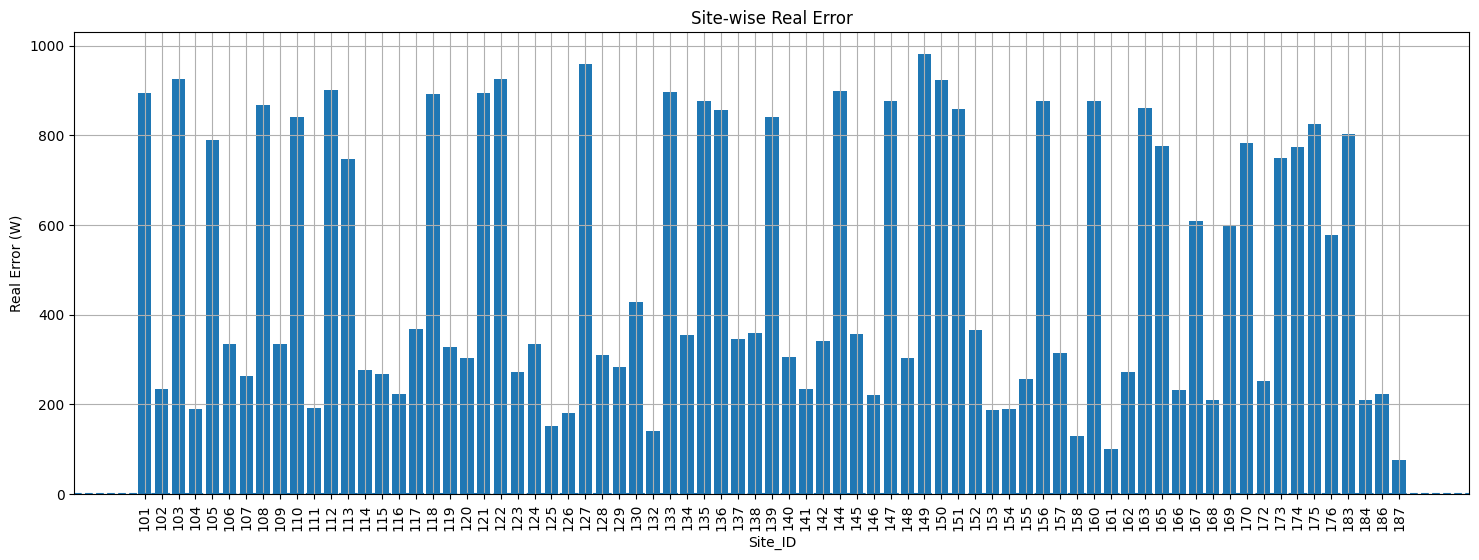

In [47]:
# ============================================================
# REAL ERROR
# = site_power - site_total_predicted_power
# SORTED BY SITE_ID
# ============================================================

summary_df['real_error'] = (summary_df['site_power']-summary_df['site_total_predicted_power'])

# ============================================================
# SORT BY SITE_ID
# ============================================================

summary_df_real_sorted = summary_df.sort_values(by='Site_ID',ascending=True)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(18,6))
plt.bar(summary_df_real_sorted['Site_ID'].astype(str),summary_df_real_sorted['real_error'])

# Zero reference line

plt.axhline(y=0,linestyle='--')

plt.xlabel('Site_ID')
plt.ylabel('Real Error (W)')
plt.title('Site-wise Real Error')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()